In [1]:
import pandas as pd

df = pd.read_csv('Data/fake_job_postings.csv')
print(df.shape)
df.head()

(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [2]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [3]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [4]:
df.groupby('fraudulent')['has_company_logo'].mean()

fraudulent
0    0.819149
1    0.326790
Name: has_company_logo, dtype: float64

In [5]:
df.groupby('fraudulent')['has_questions'].mean()


fraudulent
0    0.502057
1    0.288684
Name: has_questions, dtype: float64

In [6]:
df['desc_len'] = df['description'].fillna('').apply(len)
df.groupby('fraudulent')['desc_len'].mean()

fraudulent
0    1221.219701
1    1154.834873
Name: desc_len, dtype: float64

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [8]:
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
df[text_cols] = df[text_cols].fillna('')
df['full_text'] = df[text_cols].apply(lambda row: ' '.join(row), axis=1)
df['clean_text'] = df['full_text'].apply(clean_text)

df[['full_text', 'clean_text']].head(2)

,full_text,clean_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern we re food and we ve created ...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 2))

In [10]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, y_train, y_test = train_test_split(
    df['clean_text'], df['fraudulent'],
    test_size=0.2, random_state=42, stratify=df['fraudulent']
)

print("Train size:", len(y_train))
print("Test size:", len(y_test))

Train size: 14304
Test size: 3576


In [11]:
X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)

In [12]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(14304, 3000)
(3576, 3000)


In [13]:
df['has_salary'] = df['salary_range'].notnull().astype(int)
df['has_company_profile'] = df['company_profile'].notnull().astype(int)

structured_cols = ['telecommuting', 'has_company_logo', 'has_questions', 'has_salary', 'has_company_profile']

In [14]:
structured_cols = ['telecommuting', 'has_company_logo', 'has_questions', 'has_salary', 'has_company_profile']

X_text_train, X_text_test, X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    df['clean_text'], df[structured_cols], df['fraudulent'],
    test_size=0.2, random_state=42, stratify=df['fraudulent']
)

print(X_struct_train.shape, X_struct_test.shape)

(14304, 5) (3576, 5)


In [15]:
X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)

In [16]:
from scipy.sparse import hstack, csr_matrix

X_train_final = hstack([X_train_tfidf, csr_matrix(X_struct_train)])
X_test_final = hstack([X_test_tfidf, csr_matrix(X_struct_test)])

print(X_train_final.shape)
print(X_test_final.shape)

(14304, 3005)
(3576, 3005)


In [17]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_final, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
y_pred = logreg.predict(X_test_final)


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Real', 'Fraudulent']))

              precision    recall  f1-score   support

        Real       1.00      0.96      0.98      3403
  Fraudulent       0.51      0.91      0.66       173

    accuracy                           0.95      3576
   macro avg       0.75      0.93      0.82      3576
weighted avg       0.97      0.95      0.96      3576



In [20]:
from sklearn.metrics import precision_recall_curve, auc

y_proba = logreg.predict_proba(X_test_final)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.8580


In [21]:
!pip install xgboost


   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 8.3 MB/s eta 0:00:09
   - -------------------------------------- 1.8/69.5 MB 4.7 MB/s eta 0:00:15
   - -------------------------------------- 2.6/69.5 MB 3.8 MB/s eta 0:00:18
   -- ------------------------------------- 3.7/69.5 MB 4.2 MB/s eta 0:00:16
   -- ------------------------------------- 4.5/69.5 MB 4.2 MB/s eta 0:00:16
   --- ------------------------------------ 5.2/69.5 MB 4.1 MB/s eta 0:00:16
   --- ------------------------------------ 6.0/69.5 MB 4.1 MB/s eta 0:00:16
   --- ------------------------------------ 6.8/69.5 MB 4.1 MB/s eta 0:00:16
   ---- ----------------------------------- 7.6/69.5 MB 4.0 MB/s eta 0:00:16
   ---- ----------------------------------- 8.4/69.5 MB 4.0 MB/s eta 0:00:16
   ----- -----------

In [22]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

19.64069264069264


In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42
)
xgb.fit(X_train_final, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'aucpr'


In [24]:
y_pred_xgb = xgb.predict(X_test_final)
print(classification_report(y_test, y_pred_xgb, target_names=['Real', 'Fraudulent']))

              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3403
  Fraudulent       0.82      0.83      0.83       173

    accuracy                           0.98      3576
   macro avg       0.90      0.91      0.91      3576
weighted avg       0.98      0.98      0.98      3576



In [25]:
y_proba_xgb = xgb.predict_proba(X_test_final)[:, 1]
precision_x, recall_x, _ = precision_recall_curve(y_test, y_proba_xgb)
pr_auc_xgb = auc(recall_x, precision_x)

print(f"PR-AUC (XGBoost): {pr_auc_xgb:.4f}")

PR-AUC (XGBoost): 0.9189


In [26]:
!pip install shap



   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [27]:
import shap

explainer = shap.TreeExplainer(xgb)

In [28]:
import numpy as np

sample_idx = np.random.RandomState(42).choice(X_test_final.shape[0], size=500, replace=False)
X_sample = X_test_final[sample_idx].toarray()

shap_values = explainer.shap_values(X_sample)

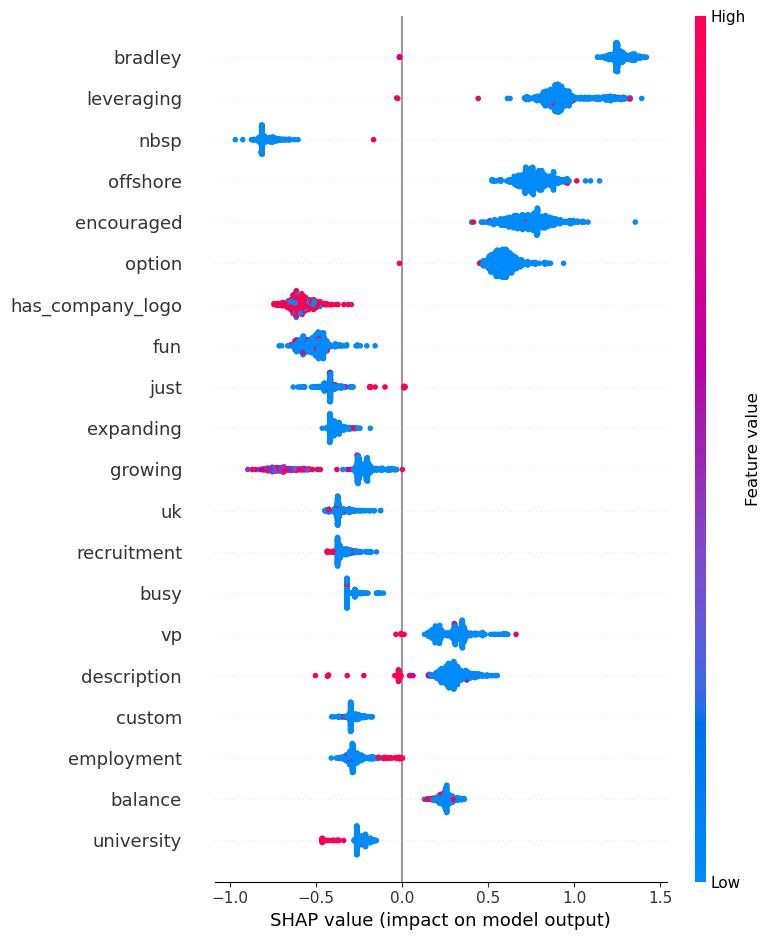

In [29]:
feature_names = tfidf.get_feature_names_out().tolist() + structured_cols

shap.summary_plot(shap_values, X_sample, feature_names=feature_names, max_display=20)

In [30]:
df['clean_text'].str.contains('bradley').sum(), df['clean_text'].str.contains('nbsp').sum()

(np.int64(102), np.int64(156))

In [31]:
df[df['clean_text'].str.contains('bradley')]['fraudulent'].value_counts()

fraudulent
0    94
1     8
Name: count, dtype: int64

In [32]:
df[df['clean_text'].str.contains('nbsp')]['fraudulent'].value_counts()

fraudulent
0    155
1      1
Name: count, dtype: int64

In [33]:
import html

def clean_text_v2(text):
    text = html.unescape(text)  # converts &nbsp; -> space, &amp; -> &, etc.
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [36]:
df['clean_text'] = df['full_text'].apply(clean_text_v2)

# quick check - did nbsp actually get removed now?
df['clean_text'].str.contains('nbsp').sum()

np.int64(0)

In [37]:
X_text_train, X_text_test, X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    df['clean_text'], df[structured_cols], df['fraudulent'],
    test_size=0.2, random_state=42, stratify=df['fraudulent']
)

X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)

X_train_final = hstack([X_train_tfidf, csr_matrix(X_struct_train)])
X_test_final = hstack([X_test_tfidf, csr_matrix(X_struct_test)])

print(X_train_final.shape, X_test_final.shape)

(14304, 3005) (3576, 3005)


In [38]:
y_pred_xgb = xgb.predict(X_test_final)
print(classification_report(y_test, y_pred_xgb, target_names=['Real', 'Fraudulent']))

y_proba_xgb = xgb.predict_proba(X_test_final)[:, 1]
precision_x, recall_x, _ = precision_recall_curve(y_test, y_proba_xgb)
pr_auc_xgb = auc(recall_x, precision_x)
print(f"PR-AUC (XGBoost): {pr_auc_xgb:.4f}")

              precision    recall  f1-score   support

        Real       0.97      0.93      0.95      3403
  Fraudulent       0.27      0.47      0.34       173

    accuracy                           0.91      3576
   macro avg       0.62      0.70      0.65      3576
weighted avg       0.94      0.91      0.92      3576

PR-AUC (XGBoost): 0.2309


In [39]:
print(y_train.mean())
print(y_test.mean())

0.04844798657718121
0.04837807606263982


In [40]:
print(structured_cols)
df[structured_cols].isnull().sum()


['telecommuting', 'has_company_logo', 'has_questions', 'has_salary', 'has_company_profile']


telecommuting          0
has_company_logo       0
has_questions          0
has_salary             0
has_company_profile    0
dtype: int64

In [41]:
X_text_train, X_text_test, X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    df['clean_text'], df[structured_cols], df['fraudulent'],
    test_size=0.2, random_state=42, stratify=df['fraudulent']
)

X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)

X_train_final = hstack([X_train_tfidf, csr_matrix(X_struct_train)])
X_test_final = hstack([X_test_tfidf, csr_matrix(X_struct_test)])

In [42]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_final, y_train)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='aucpr', random_state=42
)
xgb.fit(X_train_final, y_train)

print("Retrained fresh.")

Retrained fresh.


In [43]:
y_pred_xgb = xgb.predict(X_test_final)
print(classification_report(y_test, y_pred_xgb, target_names=['Real', 'Fraudulent']))

y_proba_xgb = xgb.predict_proba(X_test_final)[:, 1]
precision_x, recall_x, _ = precision_recall_curve(y_test, y_proba_xgb)
pr_auc_xgb = auc(recall_x, precision_x)
print(f"PR-AUC (XGBoost): {pr_auc_xgb:.4f}")

              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3403
  Fraudulent       0.82      0.82      0.82       173

    accuracy                           0.98      3576
   macro avg       0.91      0.90      0.91      3576
weighted avg       0.98      0.98      0.98      3576

PR-AUC (XGBoost): 0.9162


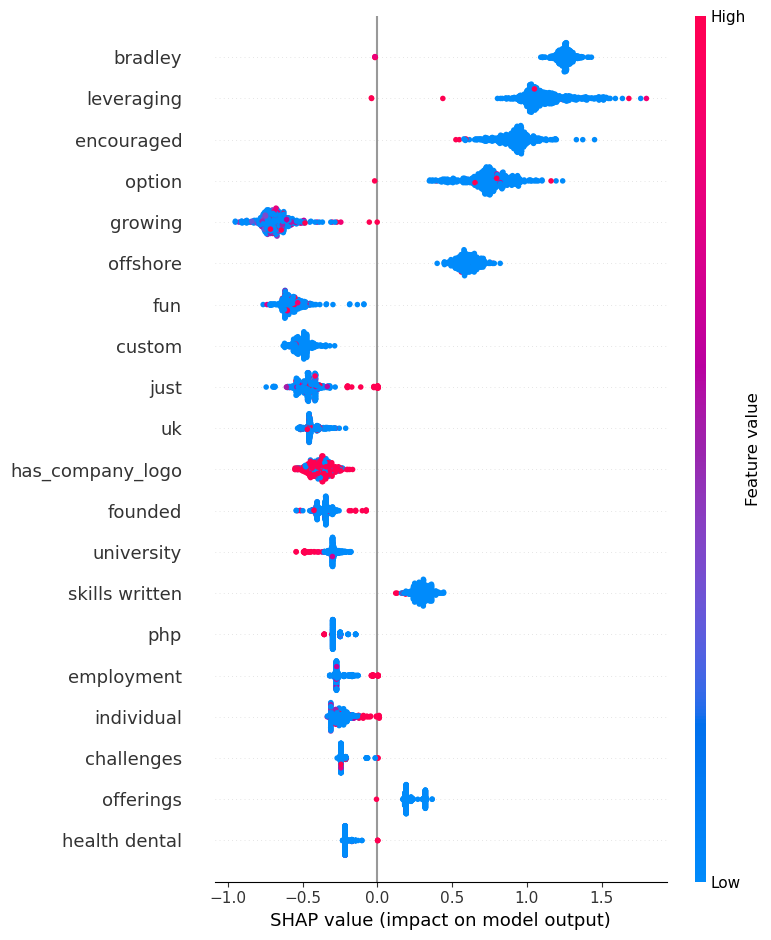

In [44]:
explainer = shap.TreeExplainer(xgb)
sample_idx = np.random.RandomState(42).choice(X_test_final.shape[0], size=500, replace=False)
X_sample = X_test_final[sample_idx].toarray()
shap_values = explainer.shap_values(X_sample)

feature_names = tfidf.get_feature_names_out().tolist() + structured_cols
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, max_display=20)

In [45]:
import joblib

joblib.dump(xgb, 'model_xgb.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(structured_cols, 'structured_cols.joblib')

print("Saved successfully.")

Saved successfully.


In [46]:
importances = xgb.feature_importances_
feature_names = tfidf.get_feature_names_out().tolist() + structured_cols

feat_imp = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
feat_imp[:20]

[('quality candidates', np.float32(0.036331974)),
 ('encouraged', np.float32(0.025272628)),
 ('average', np.float32(0.02260614)),
 ('finding', np.float32(0.02064736)),
 ('work home', np.float32(0.020248458)),
 ('ensures', np.float32(0.018982818)),
 ('time permanent', np.float32(0.013926383)),
 ('real estate', np.float32(0.013675313)),
 ('inquiries', np.float32(0.012763658)),
 ('has_company_logo', np.float32(0.012620776)),
 ('corporation', np.float32(0.011497324)),
 ('controls', np.float32(0.011057824)),
 ('door', np.float32(0.010805638)),
 ('cb', np.float32(0.010285658)),
 ('guests', np.float32(0.010118874)),
 ('nationwide', np.float32(0.009213265)),
 ('leveraging', np.float32(0.008678808)),
 ('hiring process', np.float32(0.008080532)),
 ('growing', np.float32(0.007937535)),
 ('efforts', np.float32(0.0075889993))]

In [47]:
custom_stopwords = ['bradley']  # add more words here if we spot others later

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
all_stopwords = list(ENGLISH_STOP_WORDS) + custom_stopwords

tfidf = TfidfVectorizer(max_features=3000, stop_words=all_stopwords, ngram_range=(1, 2))

In [48]:
X_text_train, X_text_test, X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    df['clean_text'], df[structured_cols], df['fraudulent'],
    test_size=0.2, random_state=42, stratify=df['fraudulent']
)

X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)

X_train_final = hstack([X_train_tfidf, csr_matrix(X_struct_train)])
X_test_final = hstack([X_test_tfidf, csr_matrix(X_struct_test)])

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_final, y_train)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='aucpr', random_state=42
)
xgb.fit(X_train_final, y_train)

print("Retrained.")

Retrained.


In [49]:
y_pred_xgb = xgb.predict(X_test_final)
print(classification_report(y_test, y_pred_xgb, target_names=['Real', 'Fraudulent']))

y_proba_xgb = xgb.predict_proba(X_test_final)[:, 1]
precision_x, recall_x, _ = precision_recall_curve(y_test, y_proba_xgb)
pr_auc_xgb = auc(recall_x, precision_x)
print(f"PR-AUC (XGBoost): {pr_auc_xgb:.4f}")

              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3403
  Fraudulent       0.82      0.80      0.81       173

    accuracy                           0.98      3576
   macro avg       0.90      0.90      0.90      3576
weighted avg       0.98      0.98      0.98      3576

PR-AUC (XGBoost): 0.9125


In [50]:
joblib.dump(xgb, 'model_xgb.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(structured_cols, 'structured_cols.joblib')

print("Saved.")

Saved.
